# Support Vector Machine (SVM)

SVM finds a straight line (in 2D) that separates the classes while **maximizing the margin** to the closest points (support vectors).

We build a simple SVM classifier on trading data (SPY) to predict next-day direction using lagged returns.


## Import Data

We load SPY via `yfinance`. If that is unavailable, we read from `../data/SPY.csv`.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Data load:CSV

path = '../data/'
df = pd.read_csv(path + 'SPY.csv', index_col=0)

df = df[['Close']].copy()
df.head(3)

,Close
Date,
2018-12-31,2506.850098
2019-01-02,2510.030029
2019-01-03,2447.889893


## Dependent and Independent Variables

We define lagged returns as features and a binary target (1 if today's return > 0 else 0). We keep the last 20% for testing to respect time order.


In [2]:
# Feature engineering
df['return'] = df['Close'].pct_change()
df['1_day_lag_returns'] = df['return'].shift(1)
df['2_day_lag_returns'] = df['return'].shift(2)
df['target'] = (df['return'] > 0).astype(int)
df = df.dropna()

features = ['1_day_lag_returns', '2_day_lag_returns']
X = df[features]
y = df['target']

# Time-aware split: last 20% as test
test_frac = 0.20
split = int(len(df) * (1 - test_frac))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print('X_train:', X_train.shape, 'X_test:', X_test.shape)

X_train: (318, 2) X_test: (80, 2)


<a id='model'></a>

## SVM Classification Model
We will use `SVC` from the `sklearn.svm` library.

**Syntax:**
```python
SVC(kernel='linear', C=1.0)
```

**Parameters used:**
- `kernel='linear'` (straight-line boundary)
- `C=1.0` (regularization; higher C = weaker regularization)


In [3]:
# Create and fit the model
svc = SVC(kernel='linear', C=1.0)
svc.fit(X_train, y_train)
print('Model:', svc)

# Optional short peek at parameters (linear kernel exposes coef_/intercept_)
print('coef_:', svc.coef_)
print('intercept_:', svc.intercept_)

Model: SVC(kernel='linear')
coef_: [[-0.00373721  0.01866848]]
intercept_: [1.0001825]


<a id='predict'></a>

## Predict & Evaluate
We predict on the test set, report test accuracy and the confusion matrix.


In [4]:
y_pred = svc.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print('Test accuracy:', round(acc, 4))
print('Confusion matrix (rows=true, cols=pred):\n', cm)

Test accuracy: 0.625
Confusion matrix (rows=true, cols=pred):
 [[ 0 30]
 [ 0 50]]


<a id='plot'></a>

## Decision Regions (optional)
A 2D plot showing predicted regions for class 0 and 1 over the lagged-return space with test points overlaid.


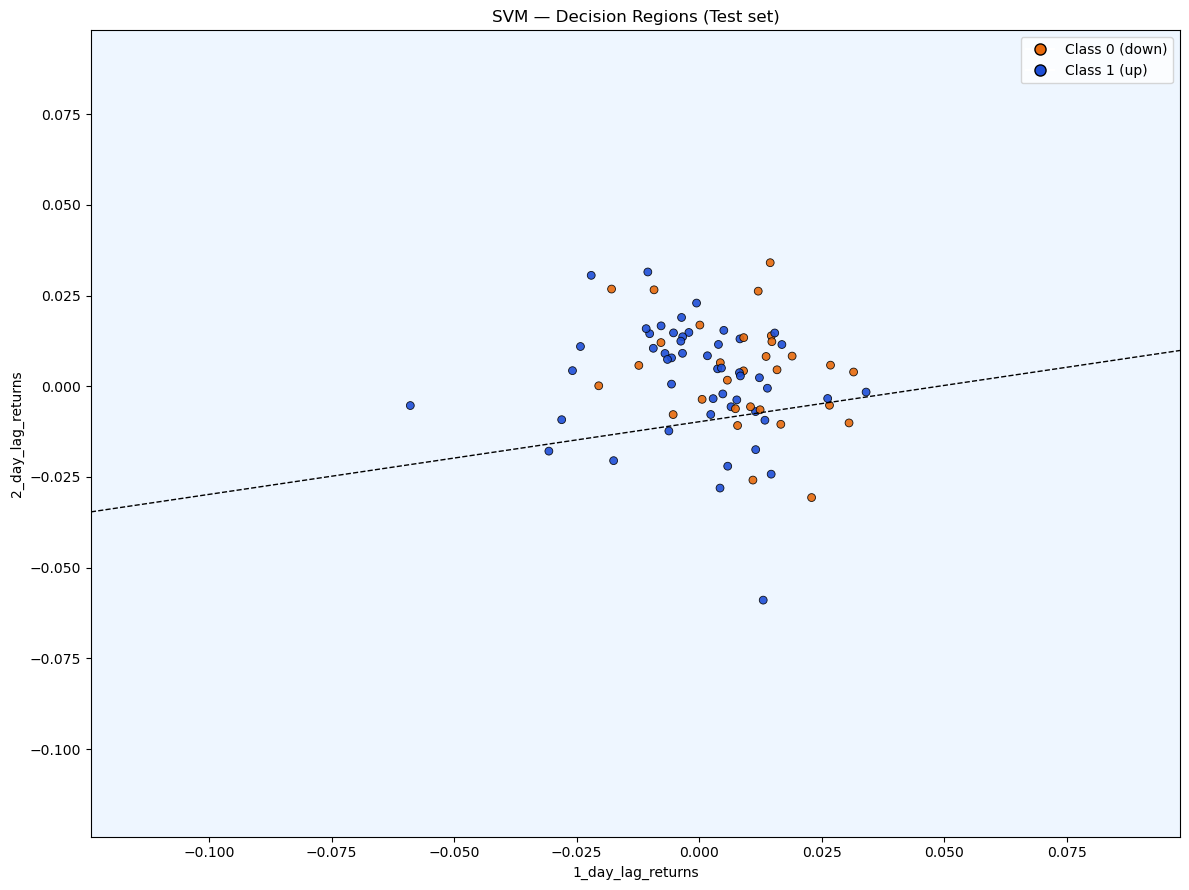

In [5]:
# === 1) Mesh builder ===
def build_mesh(XA, f1, f2, n=250):
    x1_lo, x1_hi = XA[f1].min(), XA[f1].max()
    x2_lo, x2_hi = XA[f2].min(), XA[f2].max()
    pad1 = 0.02*(x1_hi - x1_lo) or 1e-6
    pad2 = 0.02*(x2_hi - x2_lo) or 1e-6
    x1_lo, x1_hi = x1_lo - pad1, x1_hi + pad1
    x2_lo, x2_hi = x2_lo - pad2, x2_hi + pad2
    xx, yy = np.meshgrid(np.linspace(x1_lo, x1_hi, n),
                         np.linspace(x2_lo, x2_hi, n))
    return x1_lo, x1_hi, x2_lo, x2_hi, xx, yy

# === 2) Features to plot ===
f1, f2 = features[0], features[1]

# start with TEST range
x1_lo, x1_hi, x2_lo, x2_hi, xx, yy = build_mesh(X_test, f1, f2)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = svc.predict(grid).reshape(xx.shape)

# If boundary not visible (all one class), expand to FULL data range
if np.unique(Z).size == 1:
    x1_lo, x1_hi, x2_lo, x2_hi, xx, yy = build_mesh(X, f1, f2)
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = svc.predict(grid).reshape(xx.shape)

# === 3) Colors ===
cmap_light = ListedColormap(['#FFE4C7', '#CFE8FF'])   # background
cmap_bold  = ListedColormap(['#E86A0C', '#1E4FD7'])   # points

# === 4) Plot ===
plt.figure(figsize=(12, 9))
# background regions for classes {0,1}
plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=cmap_light, alpha=0.35)

# test points colored by true class {0,1}
plt.scatter(
    X_test[f1], X_test[f2],
    c=y_test.to_numpy(), cmap=cmap_bold, vmin=0, vmax=1,
    s=32, edgecolor='k', linewidth=0.6, alpha=0.9, zorder=2
)

# decision boundary & margins (linear SVM exposes decision_function)
df_grid = svc.decision_function(grid).reshape(xx.shape)
plt.contour(xx, yy, df_grid, levels=[0], colors='k', linewidths=1.5)       # boundary
plt.contour(xx, yy, df_grid, levels=[-1, 1], colors='k', linewidths=1,
            linestyles='--')                                               # margins

# legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Class 0 (down)',
           markerfacecolor=cmap_bold(0), markeredgecolor='k', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Class 1 (up)',
           markerfacecolor=cmap_bold(1), markeredgecolor='k', markersize=8),
]
plt.legend(handles=legend_handles, loc='upper right', frameon=True)

plt.xlabel(f1); plt.ylabel(f2)
plt.title('SVM — Decision Regions (Test set)')
plt.xlim(x1_lo, x1_hi); plt.ylim(x2_lo, x2_hi)
plt.tight_layout(); plt.show()


<a id='svm-toy'></a>

## SVM hyperplane (toy demo)

**Purpose:** illustrate what a linear SVM learns — one separating line and two margin lines.

**Read it:**
- Solid line = **decision boundary** where the SVM score = 0.
- Dashed lines = **margins** at score = ±1.
- **Support vectors** lie on or inside the margins and determine the boundary.
- The margin width reflects the trade-off set by **C** (lower C → wider margin, higher C → tighter fit).

This is a geometry demo only. In the SPY section we keep the same 2-feature pipeline and report **test accuracy** and the **confusion matrix**; the toy plot builds intuition for what the SVM is doing.


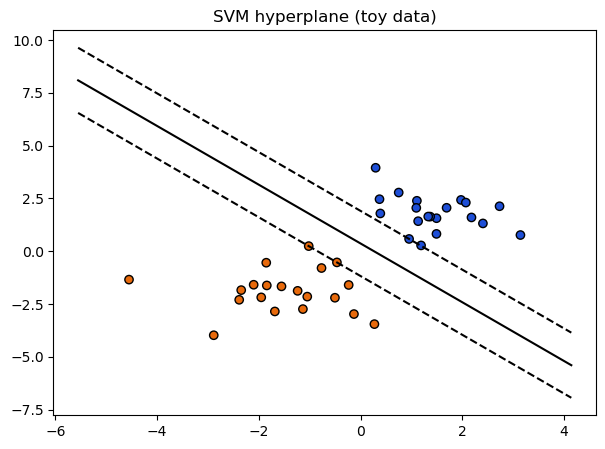

In [6]:
# Optional: toy demo to show hyperplane & margins

np.random.seed(0)
X_toy = np.r_[np.random.randn(20,2)-[2,2], np.random.randn(20,2)+[2,2]]
y_toy = np.r_[np.zeros(20), np.ones(20)]
svc_toy = SVC(kernel='linear', C=1.0).fit(X_toy, y_toy)
w = svc_toy.coef_.ravel(); b = float(svc_toy.intercept_)
xx = np.linspace(X_toy[:,0].min()-1, X_toy[:,0].max()+1, 200)
yy = -(w[0]/w[1])*xx - b/w[1]
yy_up = yy + 1.0/w[1]; yy_down = yy - 1.0/w[1]
plt.figure(figsize=(7,5))
plt.plot(xx, yy, 'k-'); plt.plot(xx, yy_up, 'k--'); plt.plot(xx, yy_down, 'k--')
plt.scatter(X_toy[:,0], X_toy[:,1], c=y_toy, cmap=ListedColormap(['#E86A0C','#1E4FD7']), edgecolor='k')
plt.title('SVM hyperplane (toy data)'); plt.show()
